In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#from sklearn.preprocessing import LabelEncoder


In [42]:
#Load ans explore datasets 
print("loading data sets..")

booking_df = pd.read_csv(r"..\data\rawdata\bookings.csv")
customers_df = pd.read_csv(r"..\data\rawdata\customers.csv")
drivers_df = pd.read_csv(r"..\data\rawdata\drivers.csv")
location_Demand_df = pd.read_csv(r"..\data\rawdata\location_demand.csv")
time_features_df = pd.read_csv(r"..\data\rawdata\time_features.csv")

print("All datasets loaded ")

loading data sets..
All datasets loaded 


shapes of Booking datasets
(100000, 22)

**********************************Info************************************
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   booking_id               100000 non-null  str    
 1   booking_date             100000 non-null  str    
 2   booking_time             100000 non-null  str    
 3   day_of_week              100000 non-null  str    
 4   is_weekend               100000 non-null  int64  
 5   hour_of_day              100000 non-null  int64  
 6   city                     100000 non-null  str    
 7   pickup_location          100000 non-null  str    
 8   drop_location            100000 non-null  str    
 9   vehicle_type             100000 non-null  str    
 10  ride_distance_km         100000 non-null  float64
 11  estimated_ride_time_min  100000 non-null  float64
 12  actual_rid

,is_weekend,hour_of_day,ride_distance_km,estimated_ride_time_min,actual_ride_time_min,base_fare,surge_multiplier,booking_value
count,100000.000000,100000.00000,100000.000000,100000.000000,68346.000000,100000.000000,100000.000000,100000.000000
mean,0.284270,11.50605,13.028289,61.384020,61.447278,211.678063,1.588973,336.344779
std,0.451068,6.91998,6.928495,39.299418,39.684246,120.908740,0.325193,208.017661
min,0.000000,0.00000,1.000000,3.000000,2.750000,28.020000,1.000000,27.280000
25%,0.000000,5.00000,7.040000,29.887500,29.870000,118.627500,1.300000,179.210000
50%,0.000000,12.00000,13.030000,55.430000,55.690000,187.345000,1.600000,290.090000
75%,1.000000,17.00000,19.032500,86.060000,84.570000,287.462500,1.800000,448.470000
max,1.000000,23.00000,25.000000,164.980000,197.340000,529.960000,2.300000,1265.590000



********************Missing values in Booking Datatest********************
actual_ride_time_min      31654
incomplete_ride_reason    91630
dtype: int64

********************Heatmap of Booking dataset********************


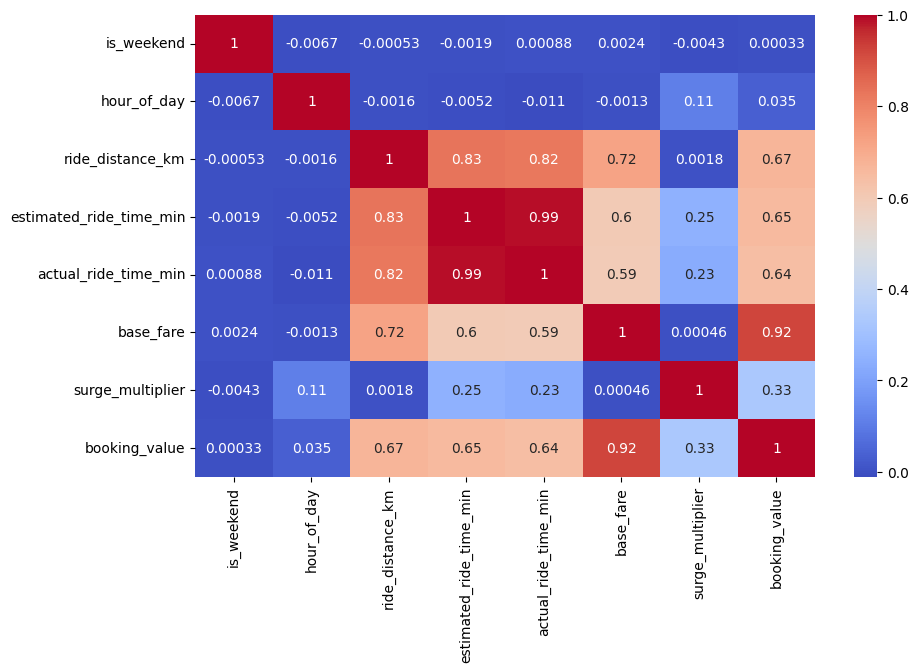

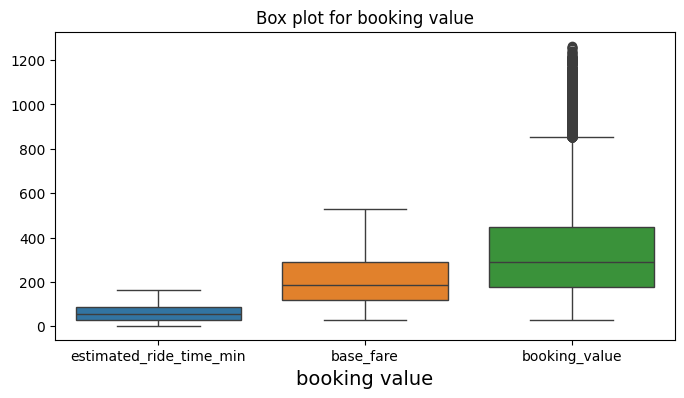

booking_status
Completed     68346
Cancelled     23284
Incomplete     8370
Name: count, dtype: int64
weather_condition
Heavy Rain    33616
Clear         33200
Rain          33184
Name: count, dtype: int64


In [31]:
#Check basics of booking_df
print("shapes of Booking datasets")
print(booking_df.shape)

#Basic info about booking_df dataset
print("\n**********************************Info************************************")
print(booking_df.info())

#Statistical summary
print("\n*********************************Statistics******************************-")
display(booking_df.describe())

#Check missing values in data set
print("\n" + "*"*20 +"Missing values in Booking Datatest" +"*"*20)
missing_values = booking_df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "✅ No missing values found!")


# Heatmap 
print("\n" + "*"*20 +"Heatmap of Booking dataset" +"*"*20)
bookingHeatmap, ax = plt.subplots(figsize =(10,6))
sns.heatmap(booking_df.select_dtypes(include="number").corr(), annot=True,cmap="coolwarm", ax=ax) 
plt.show(bookingHeatmap)

# Check outliers in data set  - Box plot
plt.figure(figsize=(8,4))

cols = ["estimated_ride_time_min","base_fare","booking_value",]
sns.boxplot(data=booking_df[cols])

plt.title("Box plot for booking value")
plt.xlabel("booking value",fontsize=14)
plt.show()

# Check if data is standarized or not 
print(booking_df["booking_status"].value_counts())
print(booking_df["weather_condition"].value_counts())




In [32]:
#Check basics of customers_df
print("shapes of Booking datasets")
print(customers_df.shape)

#Basic info about customers_df dataset
print("\n**********************************Customer dataset Info************************************")
print(customers_df.info())

#Statistical summary
print("\n*********************************Customer datatset Statistics******************************-")
display(customers_df.describe())

#Check missing values in data set
print("\n" + "*"*20 +"Missing values in customers Datatest" +"*"*20)
missing_values = customers_df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "✅ No missing values found!")






shapes of Booking datasets
(10000, 13)

**********************************Customer dataset Info************************************
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  str    
 1   customer_gender           10000 non-null  str    
 2   customer_age              10000 non-null  int64  
 3   customer_city             10000 non-null  str    
 4   customer_signup_days_ago  10000 non-null  int64  
 5   preferred_vehicle_type    10000 non-null  str    
 6   total_bookings            10000 non-null  int64  
 7   completed_rides           10000 non-null  int64  
 8   cancelled_rides           10000 non-null  int64  
 9   incomplete_rides          10000 non-null  int64  
 10  cancellation_rate         10000 non-null  float64
 11  avg_customer_rating       10000 non-null  float64
 

,customer_age,customer_signup_days_ago,total_bookings,completed_rides,cancelled_rides,incomplete_rides,cancellation_rate,avg_customer_rating,customer_cancel_flag
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.054000,517.500700,10.000000,6.834600,2.328400,0.837000,0.232783,4.252350,0.534300
std,13.484104,280.655533,3.184684,2.624982,1.531597,0.918649,0.142207,0.437307,0.498847
min,18.000000,30.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.500000,0.000000
25%,30.000000,276.000000,8.000000,5.000000,1.000000,0.000000,0.133333,3.900000,0.000000
50%,41.000000,520.500000,10.000000,7.000000,2.000000,1.000000,0.222222,4.300000,1.000000
75%,53.000000,763.000000,12.000000,9.000000,3.000000,1.000000,0.333333,4.600000,1.000000
max,64.000000,999.000000,26.000000,20.000000,10.000000,5.000000,1.000000,5.000000,1.000000



********************Missing values in customers Datatest********************
✅ No missing values found!


In [ ]:
#Check basics of drivers_df
print("shapes of drivers datasets")
print(drivers_df.shape)

#Basic info about customers_df dataset
print("\n**********************************drivers dataset Info************************************")
print(drivers_df.info())

#Statistical summary
print("\n*********************************drivers datatset Statistics******************************-")
display(drivers_df.describe())

#Check missing values in data set
print("\n" + "*"*20 +"Missing values in drivers Datatest" +"*"*20)
missing_values = drivers_df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "✅ No missing values found!")



In [ ]:
#Check basics of drivers_df
print("shapes of location_Demand_df datasets")
print(location_Demand_df.shape)

#Basic info about location_Demand_df dataset
print("\n**********************************location_Demand dataset Info************************************")
print(location_Demand_df.info())

#Statistical summary
print("\n*********************************location_Demand datatset Statistics******************************-")
display(location_Demand_df.describe())

#Check missing values in data set
print("\n" + "*"*20 +"Missing values in location_Demand Datatest" +"*"*20)
missing_values = location_Demand_df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "✅ No missing values found!")



In [ ]:
#Check basics of drivers_df
print("shapes of time_features_df datasets")
print(time_features_df.shape)

#Basic info about time_features_df dataset
print("\n**********************************time_features_df dataset Info************************************")
print(time_features_df.info())

#Statistical summary
print("\n*********************************time_features_df datatset Statistics******************************-")
display(time_features_df.describe())

#Check missing values in data set
print("\n" + "*"*20 +"Missing values in time_features_df Datatest" +"*"*20)
missing_values = time_features_df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "✅ No missing values found!")



In [35]:
import os
# Prepraing Data for Driver Delay Prediction  - Binary Classification Model
rawDataForDriverDelayPrediction = booking_df.merge(drivers_df, on="driver_id", how="left")
rawDataForDriverDelayPrediction = rawDataForDriverDelayPrediction[["hour_of_day","day_of_week",
                                                                 "is_weekend","city",
                                                                  "booking_status",
                                                                  "incomplete_ride_reason",
                                                                   "pickup_location","drop_location","ride_distance_km",
                                                                   "estimated_ride_time_min","traffic_level","weather_condition",
                                                                   "vehicle_type_x","driver_experience_years",
                                                                   "total_assigned_rides","driver_delay_flag","accepted_rides","acceptance_rate",
                                                                   "delay_count","delay_rate","avg_driver_rating","avg_pickup_delay_min",
                                                                   ]]
rawDataForDriverDelayPrediction["driver_delay_ride"] = np.where(
    (rawDataForDriverDelayPrediction["booking_status"] == "Incomplete") &
    (rawDataForDriverDelayPrediction["incomplete_ride_reason"] == "Driver Delay"),
    1,
    0
)

output_dir = "../data/processedData"
os.makedirs(output_dir, exist_ok=True)

#LinearRegressionDataset
output_path = os.path.join(output_dir, "DataForDriverDelayPrediction.csv")

rawDataForDriverDelayPrediction.to_csv(output_path, index=False)
print(f"✅ File saved successfully to: {output_path}")

✅ File saved successfully to: ../data/processedData\DataForDriverDelayPrediction.csv


In [40]:
rawDataForDriverDelayPrediction["driver_delay_flag"].value_counts(normalize=True) * 100

driver_delay_flag
0    87.453
1    12.547
Name: proportion, dtype: float64

In [39]:
booking_df["incomplete_ride_reason"].value_counts()

#booking_df["customer_cancel_ride"] =  booking_df.apply(lambda : 1  if booking_df["booking_status"] =="Cancelled" and booking_df["incomplete_ride_reason"] == "Customer No-show" else 0, axis=1 )
#
#booking_df["customer_cancel_ride"] = np.where(
 #   (booking_df["booking_status"] == "Cancelled") &
 #   (booking_df["incomplete_ride_reason"] == "Customer No-show"),
#    1,
 #   0
#)

temp = booking_df.loc[
    booking_df["booking_status"] == "Incomplete"
]
temp.count()
booking_df.count()

booking_id                 100000
booking_date               100000
booking_time               100000
day_of_week                100000
is_weekend                 100000
hour_of_day                100000
city                       100000
pickup_location            100000
drop_location              100000
vehicle_type               100000
ride_distance_km           100000
estimated_ride_time_min    100000
actual_ride_time_min        68346
traffic_level              100000
weather_condition          100000
base_fare                  100000
surge_multiplier           100000
booking_value              100000
booking_status             100000
incomplete_ride_reason       8370
customer_id                100000
driver_id                  100000
driver_delay_ride          100000
dtype: int64

In [41]:
customers_df.describe()

,customer_age,customer_signup_days_ago,total_bookings,completed_rides,cancelled_rides,incomplete_rides,cancellation_rate,avg_customer_rating,customer_cancel_flag
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.054000,517.500700,10.000000,6.834600,2.328400,0.837000,0.232783,4.252350,0.534300
std,13.484104,280.655533,3.184684,2.624982,1.531597,0.918649,0.142207,0.437307,0.498847
min,18.000000,30.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.500000,0.000000
25%,30.000000,276.000000,8.000000,5.000000,1.000000,0.000000,0.133333,3.900000,0.000000
50%,41.000000,520.500000,10.000000,7.000000,2.000000,1.000000,0.222222,4.300000,1.000000
75%,53.000000,763.000000,12.000000,9.000000,3.000000,1.000000,0.333333,4.600000,1.000000
max,64.000000,999.000000,26.000000,20.000000,10.000000,5.000000,1.000000,5.000000,1.000000


In [ ]:
import os
# Prepraing Data for Customer Cancel Flag Prediction  - Binary Classification Model
rawDataForCustomerCancelPrediction = booking_df.merge(customers_df, on="customer_id", how="left")
rawDataForCustomerCancelPrediction = rawDataForCustomerCancelPrediction[["day_of_week","is_weekend",
                                                                         "hour_of_day","city","pickup_location",
                                                                         "booking_status",
                                                                         "drop_location","preferred_vehicle_type",
                                                                         "ride_distance_km","estimated_ride_time_min",
                                                                         "traffic_level","weather_condition","base_fare",
                                                                         "surge_multiplier","booking_value","customer_gender",
                                                                         "customer_age","customer_city","customer_signup_days_ago",
                                                                         "total_bookings","completed_rides","cancelled_rides",
                                                                         "vehicle_type",
                                                                         "incomplete_rides","cancellation_rate",
                                                                         "avg_customer_rating","preferred_vehicle_type","customer_cancel_flag"]]


#Create Target Column
rawDataForCustomerCancelPrediction["Customer_Cancel_Ride"] =np.where(
    (rawDataForCustomerCancelPrediction["booking_status"] == "Cancelled") &
    (rawDataForCustomerCancelPrediction["cancelled_rides"] > 3) &
    (rawDataForCustomerCancelPrediction["avg_customer_rating"] < 3.5),
    1,
    0
)

output_dir = "../data/processedData"
os.makedirs(output_dir, exist_ok=True)

#LinearRegressionDataset
output_path = os.path.join(output_dir, "DataForCustomerCancelPrediction.csv")

rawDataForCustomerCancelPrediction.to_csv(output_path, index=False)
print(f"✅ File saved successfully to: {output_path}")


KeyError: "['booking_statusdrop_location'] not in index"

In [37]:
# 🤖 Prepare Data for Fare Prediction - Linear Regression Modeling
print("🎯 Preparing data for Fare Prediction - Linear regression modeling...")

rawDataForLinearRegression = booking_df[["ride_distance_km","estimated_ride_time_min",
                                        "traffic_level","weather_condition","base_fare",
                                        "surge_multiplier","booking_value","vehicle_type",
                                        "hour_of_day"]]

rawDataForLinearRegression.info()


🎯 Preparing data for Fare Prediction - Linear regression modeling...
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   ride_distance_km         100000 non-null  float64
 1   estimated_ride_time_min  100000 non-null  float64
 2   traffic_level            100000 non-null  str    
 3   weather_condition        100000 non-null  str    
 4   base_fare                100000 non-null  float64
 5   surge_multiplier         100000 non-null  float64
 6   booking_value            100000 non-null  float64
 7   vehicle_type             100000 non-null  str    
 8   hour_of_day              100000 non-null  int64  
dtypes: float64(5), int64(1), str(3)
memory usage: 6.9 MB


In [ ]:

# 🤖 Prepare Data for Modeling
print("🎯 Preparing data for logistic regression modeling...")

rawDataForLogisticRegression = (
    booking_df
    .merge(customers_df, on="customer_id", how="left")
    .merge(drivers_df, on="driver_id", how="left")
)

rawDataForLogisticRegression.info()

#Feature Engineering 


# remove unwanted Features
colsToDrop=["booking_id","actual_ride_time_min",
            "incomplete_ride_reason","customer_id",
            "driver_id","driver_city","total_assigned_rides",
            "driver_age",""
            "accepted_rides","incomplete_rides_y","delay_count",
            "customer_gender","total_bookings","completed_rides","cancelled_rides",
            "vehicle_type_x" ,"vehicle_type_y", "incomplete_rides_x", ]
rawDataForLogisticRegression.drop(columns= colsToDrop,inplace=True)

display(rawDataForLogisticRegression)

# First, let's complete the feature engineering by encoding categorical variables  booking_df = pd.read_csv(r"..\data\bookings.csv")

#print("🔧 Encoding categorical variables...")

🎯 Preparing data for logistic regression modeling...
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   booking_id                100000 non-null  str    
 1   booking_date              100000 non-null  str    
 2   booking_time              100000 non-null  str    
 3   day_of_week               100000 non-null  str    
 4   is_weekend                100000 non-null  int64  
 5   hour_of_day               100000 non-null  int64  
 6   city                      100000 non-null  str    
 7   pickup_location           100000 non-null  str    
 8   drop_location             100000 non-null  str    
 9   vehicle_type_x            100000 non-null  str    
 10  ride_distance_km          100000 non-null  float64
 11  estimated_ride_time_min   100000 non-null  float64
 12  actual_ride_time_min      68346 non-null   float64
 13  tra

,booking_date,booking_time,day_of_week,is_weekend,hour_of_day,city,pickup_location,drop_location,ride_distance_km,estimated_ride_time_min,...,preferred_vehicle_type,cancellation_rate,avg_customer_rating,customer_cancel_flag,driver_experience_years,acceptance_rate,delay_rate,avg_driver_rating,avg_pickup_delay_min,driver_delay_flag
0,2025-12-11,00:07:00,Thursday,0,0,Mumbai,Loc_19,Loc_16,7.01,46.30,...,Bike,0.187500,4.3,0,10,0.89,0.06,4.9,2.9,0
1,2025-07-07,06:13:00,Monday,0,6,Mumbai,Loc_32,Loc_38,9.67,43.54,...,Cab,0.000000,4.7,0,5,0.78,0.06,4.6,3.9,0
2,2025-08-23,08:53:00,Saturday,1,8,Chennai,Loc_28,Loc_1,16.18,48.55,...,Cab,0.500000,3.7,1,14,0.81,0.15,4.4,5.2,1
3,2025-04-12,10:25:00,Saturday,1,10,Delhi,Loc_16,Loc_30,1.02,4.61,...,Cab,0.181818,3.7,0,14,0.68,0.08,4.2,3.2,0
4,2025-08-23,00:08:00,Saturday,1,0,Hyderabad,Loc_22,Loc_31,12.35,55.56,...,Cab,0.000000,4.4,0,4,0.80,0.07,4.5,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2025-02-09,07:32:00,Sunday,1,7,Chennai,Loc_27,Loc_10,12.32,55.42,...,Cab,0.384615,4.1,1,6,0.88,0.00,4.1,2.0,0
99996,2025-06-02,08:45:00,Monday,0,8,Mumbai,Loc_43,Loc_2,9.58,63.25,...,Cab,0.333333,3.6,1,9,0.83,0.04,4.6,1.6,0
99997,2025-08-20,03:36:00,Wednesday,0,3,Bangalore,Loc_20,Loc_38,7.57,34.06,...,Bike,0.250000,4.7,1,7,0.83,0.12,4.4,2.8,1
99998,2025-07-30,23:04:00,Wednesday,0,23,Hyderabad,Loc_5,Loc_3,22.87,150.95,...,Cab,0.111111,4.4,0,10,0.75,0.08,5.0,5.2,0


In [38]:
import os

output_dir = "../data/processedData"
os.makedirs(output_dir, exist_ok=True)

#LogisticRegression Dataset 

#output_path = os.path.join(output_dir, "DataForLogisticRegression.csv")

#rawDataForLogisticRegression.to_csv(output_path, index=False)

#LinearRegressionDataset
output_path = os.path.join(output_dir, "DataForLinearRegression.csv")

rawDataForLinearRegression.to_csv(output_path, index=False)
print(f"✅ File saved successfully to: {output_path}")

✅ File saved successfully to: ../data/processedData\DataForLinearRegression.csv


In [17]:
rawDataForLogisticRegression["ride_distance_km"].describe()
rawDataForLogisticRegression["City_Pair"] = (
    rawDataForLogisticRegression["pickup_location"] +
    "-" +
    rawDataForLogisticRegression["drop_location"]
)

df = rawDataForLogisticRegression.groupby("booking_status")["City_Pair"].count().reset_index(name='count')
 
display(df)

,booking_status,count
0,Cancelled,23284
1,Completed,68346
2,Incomplete,8370


In [19]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 11.9 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 12.7 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 2.9/37.3 MB 15.3 MB/s eta 0:00:03
   ----- ---------------------------------- 5.5/37.3 MB 14.2 MB/s eta 0:00:03
   --------- ------------------------------ 9.2/37.3 MB 15.1 MB/s eta 0:00:02
   ------------ --


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from sklearn.preprocessing import MinMaxScaler

cols = [
    "acceptance_rate",
    "avg_driver_rating",
    "driver_experience_years",
    "delay_rate",
    "avg_pickup_delay_min"
]

scaler = MinMaxScaler()

rawDataForLogisticRegression[cols] = scaler.fit_transform(rawDataForLogisticRegression[cols])

In [25]:
rawDataForLogisticRegression["Driver_Reliability_Score"] = (
      0.35 * rawDataForLogisticRegression["acceptance_rate"]
    + 0.30 * rawDataForLogisticRegression["avg_driver_rating"]
    + 0.20 * rawDataForLogisticRegression["driver_experience_years"]
    + 0.10 * (1 - rawDataForLogisticRegression["delay_rate"])
    + 0.05 * (1 - rawDataForLogisticRegression["avg_pickup_delay_min"])
)
rawDataForLogisticRegression.groupby("booking_status")["Driver_Reliability_Score"].mean()

booking_status
Cancelled     0.587049
Completed     0.612346
Incomplete    0.604839
Name: Driver_Reliability_Score, dtype: float64

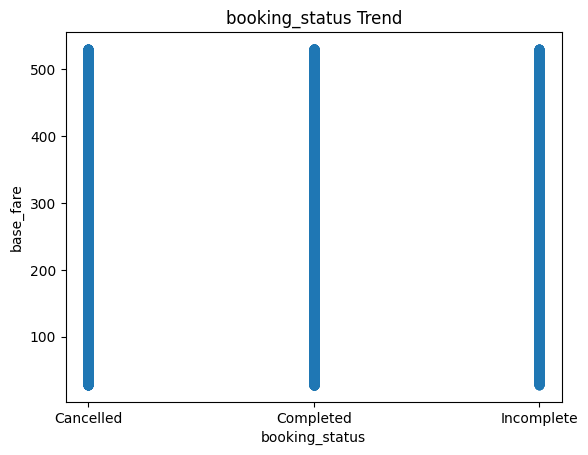

In [36]:
# Visualization
plt.scatter(rawDataForLogisticRegression['booking_status'], rawDataForLogisticRegression['base_fare'])
plt.xlabel('booking_status')
plt.ylabel('base_fare')
plt.title('booking_status Trend')
plt.show()


In [ ]:
# Visualization
plt.bar(rawDataForLogisticRegression['booking_status'], rawDataForLogisticRegression['customer_city'])
plt.xlabel('booking_status')
plt.ylabel('base_fare')
plt.title('booking_status Trend')
plt.show()
